<a href="https://colab.research.google.com/github/jwliu24/Uber-Operational-Analysis/blob/main/Week_5_Predictive_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#0f172a; color:#5eead4; padding:28px; border-radius:12px;">
  <h1 style="font-size:28px; font-family:Calibri; margin-bottom:8px;">Week 5 : Predicting Uber Ride Cancellations</h1>
  <p style="font-size:17px; font-family:Calibri; color:#e2e8f0; line-height:1.7em;">
    Every cancelled ride is lost revenue, a frustrated customer, and a signal of something going wrong.
    <br><br>
    By predicting cancellations <strong>before they happen</strong>, ride platforms can:
  </p>
  <ul style="font-size:16px; font-family:Calibri; color:#e2e8f0; line-height:2em;">
    <li>Proactively reassign drivers before a customer cancels</li>
    <li>Flag high-risk bookings for operations teams</li>
    <li>Reduce churn caused by bad first experiences</li>
  </ul>
  <p style="font-size:16px; font-family:Calibri; color:#94a3b8; margin-top:12px;">
    <strong>Task:</strong> Binary classification &nbsp;|&nbsp;
    <strong>Target:</strong> Did the customer cancel? (1 = yes, 0 = no) &nbsp;|&nbsp;
    <strong>Challenge:</strong> Only ~7% of rides are customer cancellations
  </p>
</div>

---
## Step 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)

# Optionally set up defaults for all plots
sns.set(style='whitegrid')
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## Step 2: Load & Inspect the Data

In [2]:
# Upload uber_rides_data_processed.csv when prompted
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/uber_rides_data_processed.csv'
df = pd.read_csv(file_path)

print('Column types and non-null counts:')
df.info()
df.head()

Mounted at /content/drive
Column types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 30 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,2024-03-23 12:29:38,12,Saturday,3,True
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,False,False,False,True,2024-11-29 18:01:39,18,Friday,11,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,True,False,False,False,2024-08-23 08:56:10,8,Friday,8,False
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,True,False,False,False,2024-10-21 17:17:25,17,Monday,10,False
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,True,False,False,False,2024-09-16 22:08:00,22,Monday,9,False


In [3]:
print('Booking Status breakdown:')
print(df['Booking Status'].value_counts())

Booking Status breakdown:
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


---
## Step 3: Parse Timestamps

The date and time are stored as separate text columns. We combine them into a real datetime so we can extract time-based features like hour, day of week, and weekend flag.

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce'
)

df['hour']       = df['datetime'].dt.hour
df['day']        = df['datetime'].dt.day
df['month']      = df['datetime'].dt.month
df['weekday']    = df['datetime'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

df[['datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend']].head(4)

,datetime,hour,day,month,weekday,is_weekend
0,2024-03-23 12:29:38,12,23,3,5,1
1,2024-11-29 18:01:39,18,29,11,4,0
2,2024-08-23 08:56:10,8,23,8,4,0
3,2024-10-21 17:17:25,17,21,10,0,0


In [5]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,...,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend,datetime,hour,day,month,weekday,is_weekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,2024-03-23 12:29:38,12,Saturday,3,True,2024-03-23 12:29:38,12,23,3,5,1
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,...,False,False,False,True,2024-11-29 18:01:39,18,Friday,11,False,2024-11-29 18:01:39,18,29,11,4,0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,2024-08-23 08:56:10,8,Friday,8,False,2024-08-23 08:56:10,8,23,8,4,0
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,2024-10-21 17:17:25,17,Monday,10,False,2024-10-21 17:17:25,17,21,10,0,0
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,2024-09-16 22:08:00,22,Monday,9,False,2024-09-16 22:08:00,22,16,9,0,0


---
## 🎯 Step 4: Define the Target Variable

We are predicting **customer-initiated cancellations** specifically. This is the most actionable target for product decisions - the platform can intervene when a customer is about to cancel, but has less control over driver cancellations.

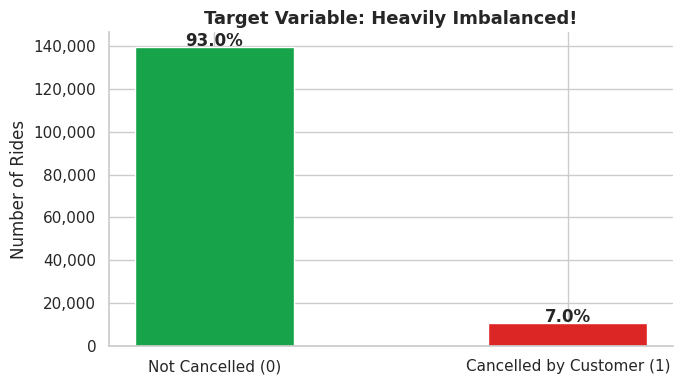

Not cancelled:             139,500  (93.0%)
Cancelled by customer:      10,500  (7.0%)

⚠️  Only 7.0% of rides are customer cancellations.
   A model that always says "not cancelled" would be 93% accurate — and totally useless.
   We'll need to handle this imbalance explicitly.


In [6]:
df['target'] = (df['Booking Status'] == 'Cancelled by Customer').astype(int)

counts = df['target'].value_counts()
pcts   = df['target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#16a34a', '#dc2626']
bars = ax.bar(['Not Cancelled (0)', 'Cancelled by Customer (1)'],
              counts.values, color=colors, width=0.45, edgecolor='white')
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Target Variable: Heavily Imbalanced!', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Rides')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'Not cancelled:            {counts[0]:>8,}  ({pcts[0]:.1f}%)')
print(f'Cancelled by customer:    {counts[1]:>8,}  ({pcts[1]:.1f}%)')
print(f'\n⚠️  Only {pcts[1]:.1f}% of rides are customer cancellations.')
print('   A model that always says "not cancelled" would be 93% accurate — and totally useless.')
print('   We\'ll need to handle this imbalance explicitly.')

---
## 🔍 Step 5: Missing Value Strategy — Nulls Are Not Random

Before we can model, we need to decide what to do with missing values. But first: **why are values missing?**

In this dataset, missing values are not random noise - they tell a story about what happened in the ride.

In [7]:
# Look at which columns have missing values and what booking statuses they correspond to
missing_by_status = df.groupby('Booking Status')[['Driver Ratings', 'Booking Value', 'Avg VTAT']].apply(
    lambda g: g.isnull().sum()
)

print('Null counts by Booking Status:')
print(missing_by_status)
print()
print('Key insight:')
print('  - Driver Ratings is NULL for ALL cancelled rides → no ride happened, no rating given')
print('  - Booking Value is NULL for cancelled & no-driver rides → no trip, no fare')
print('  - Avg VTAT is NULL for No Driver Found → the driver never showed up')

Null counts by Booking Status:
                       Driver Ratings  Booking Value  Avg VTAT
Booking Status                                                
Cancelled by Customer           10500          10500         0
Cancelled by Driver             27000          27000         0
Completed                           0              0         0
Incomplete                       9000              0         0
No Driver Found                 10500          10500     10500

Key insight:
  - Driver Ratings is NULL for ALL cancelled rides → no ride happened, no rating given
  - Booking Value is NULL for cancelled & no-driver rides → no trip, no fare
  - Avg VTAT is NULL for No Driver Found → the driver never showed up


### ⚠️ The Leakage Trap

Because `Driver Ratings` and `Booking Value` are **null only when a ride is cancelled**, using a flag like `missing_driver_rating = 1` as a feature would be **data leakage** — the model would be "cheating" by learning information that is only known *after* the outcome.

Good predictive models only use information available **at the moment of booking**, before anything has happened.

| Column | Available at booking? | Can we use it? |
|---|---|---|
| `Avg VTAT` | ✅ Yes — estimate at dispatch time | ✅ Use it |
| `Driver Ratings` | ❌ No — filled after ride completes | ❌ Leakage |
| `Booking Value` | ❌ No — calculated after ride | ❌ Leakage |
| `Customer Rating` | ❌ No — filled after ride | ❌ Leakage |
| `hour`, `weekday` | ✅ Yes — known at booking time | ✅ Use it |
| `Vehicle Type` | ✅ Yes — chosen at booking | ✅ Use it |
| `Pickup Location` | ✅ Yes — entered at booking | ✅ Use it |

In [8]:
# Fill Avg VTAT nulls with median — those are No Driver Found rows,
# we still want to use VTAT for the rides where it IS available
vtat_median = df['Avg VTAT'].median()
df['Avg VTAT'] = df['Avg VTAT'].fillna(vtat_median)

print(f'VTAT median used for fill: {vtat_median} minutes')
print(f'VTAT nulls remaining: {df["Avg VTAT"].isnull().sum()}')

VTAT median used for fill: 8.3 minutes
VTAT nulls remaining: 0


---
## Step 6: Exploratory Data Analysis

Before engineering features, we explore the data to understand *what actually drives cancellations*. The patterns we find here will directly inform the features we build.

### 6a. Cancellation Rate by Vehicle Type & Driver Rating

/tmp/ipykernel_2151/1540983454.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Cancelled', 'Cancelled'])


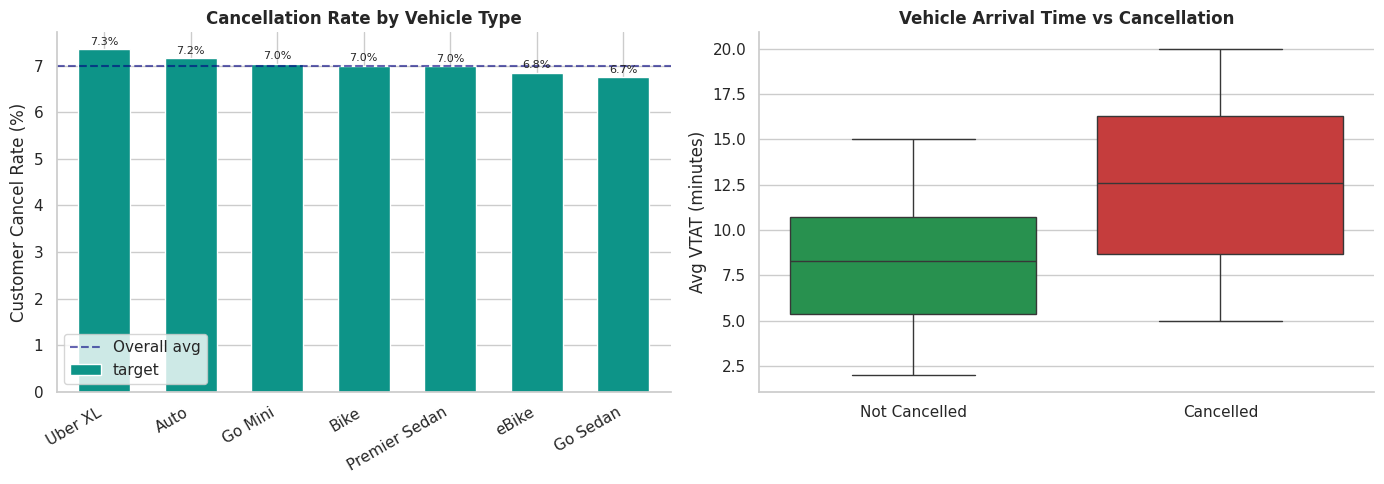

Insight: Cancelled rides have a higher median VTAT.
  Not Cancelled — median VTAT: 8.3 min
  Cancelled     — median VTAT: 12.6 min


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vehicle type
vehicle_cancel = df.groupby('Vehicle Type')['target'].mean().sort_values(ascending=False) * 100
vehicle_cancel.plot(kind='bar', ax=axes[0], color='#0d9488', edgecolor='white', width=0.6)
axes[0].set_title('Cancellation Rate by Vehicle Type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Customer Cancel Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].axhline(df['target'].mean()*100, color='navy', linestyle='--', alpha=0.6, label='Overall avg')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)

# VTAT vs cancellation (box plot)
sns.boxplot(
    data=df, x='target', y='Avg VTAT', hue='target',
    palette={0: '#16a34a', 1: '#dc2626'}, ax=axes[1], legend=False
)
axes[1].set_title('Vehicle Arrival Time vs Cancellation', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Not Cancelled', 'Cancelled'])
axes[1].set_ylabel('Avg VTAT (minutes)')

plt.tight_layout()
plt.show()

print('Insight: Cancelled rides have a higher median VTAT.')
print(f'  Not Cancelled — median VTAT: {df[df["target"]==0]["Avg VTAT"].median():.1f} min')
print(f'  Cancelled     — median VTAT: {df[df["target"]==1]["Avg VTAT"].median():.1f} min')

### 6b. Location EDA — Which Pickup Areas Have the Highest Cancel Rates?

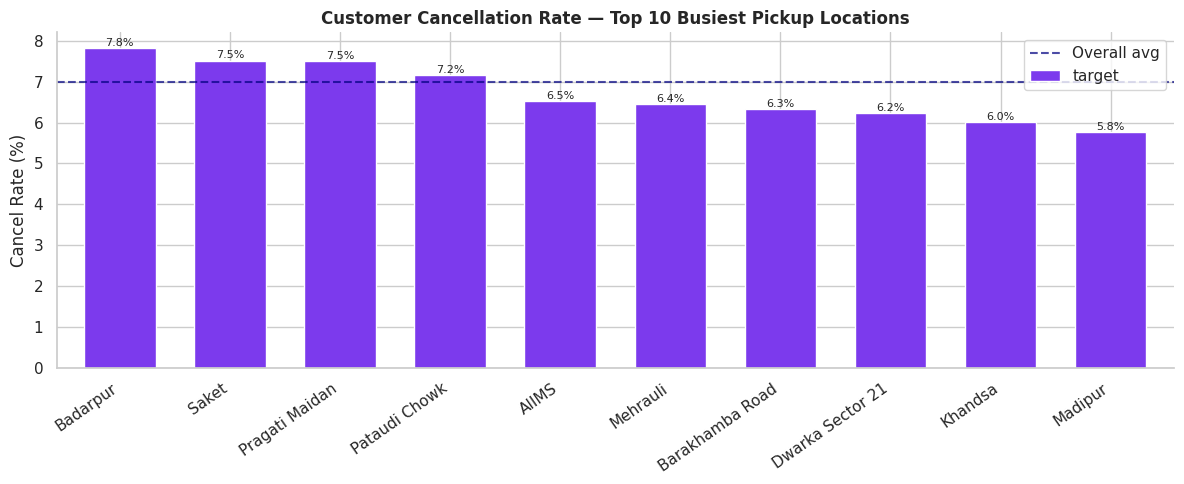

In [10]:
# Top 10 pickup locations by ride volume
top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df_top = df[df['Pickup Location'].isin(top_pickups)]

plt.figure(figsize=(12, 5))
cancel_by_loc = (
    df_top.groupby('Pickup Location')['target']
    .mean()
    .sort_values(ascending=False) * 100
)
cancel_by_loc.plot(kind='bar', color='#7c3aed', edgecolor='white', width=0.65)
plt.axhline(df['target'].mean()*100, color='navy', linestyle='--', label='Overall avg', alpha=0.7)
plt.title('Customer Cancellation Rate — Top 10 Busiest Pickup Locations', fontweight='bold')
plt.ylabel('Cancel Rate (%)')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.legend()
for i, v in enumerate(cancel_by_loc):
    plt.text(i, v + 0.05, f'{v:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 6c. Time EDA — Cancellation Rate by Hour and Day of Week

The heatmap below shows cancellation rate for every combination of hour × weekday. Darker cells = higher risk.

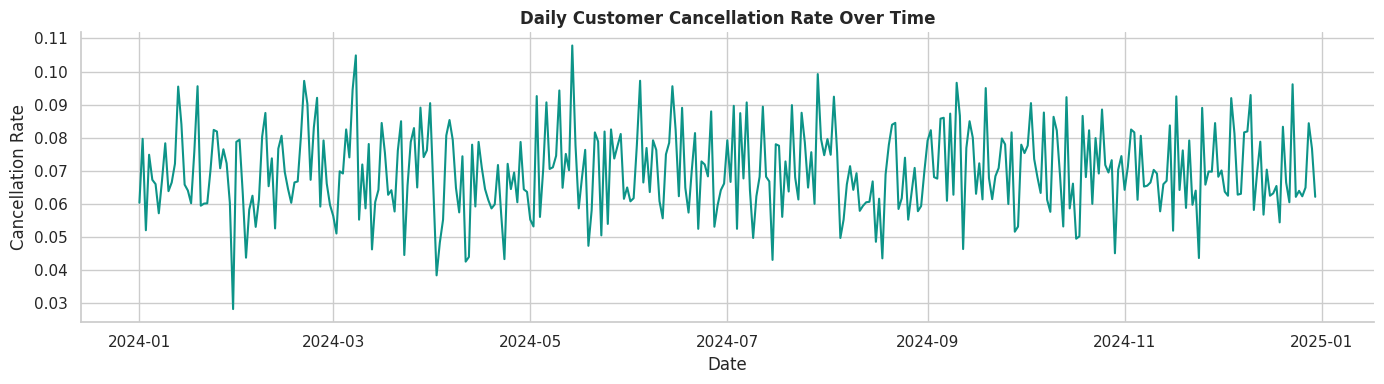

In [11]:
# Daily trend
df_daily = df.groupby('Date')['target'].mean().reset_index()

plt.figure(figsize=(14, 4))
sns.lineplot(data=df_daily, x='Date', y='target', color='#0d9488', linewidth=1.5)
plt.title('Daily Customer Cancellation Rate Over Time', fontweight='bold')
plt.ylabel('Cancellation Rate')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

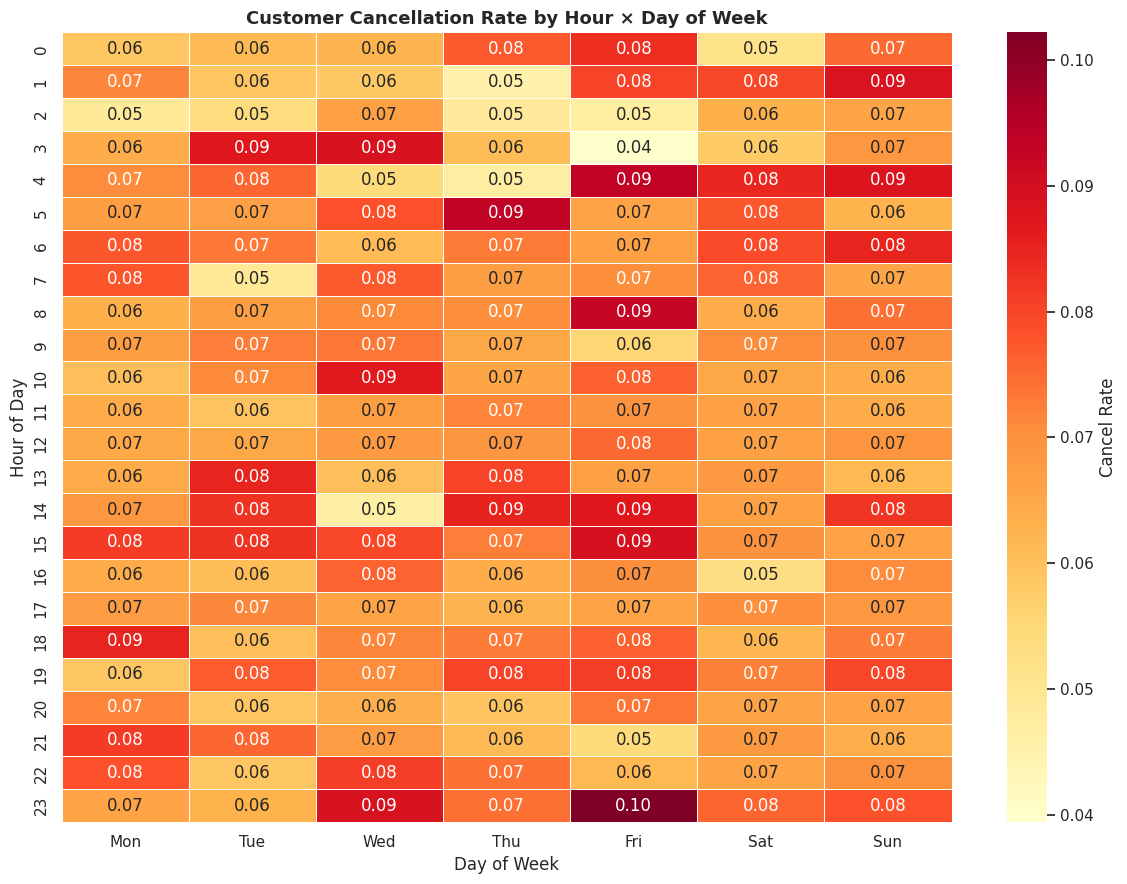

What to look for in this heatmap:
  • Darker cells = higher cancellation risk
  • Are early mornings riskier than midday?
  • Does weekend behaviour differ from weekdays?
  • These patterns are exactly what the model will learn from


In [12]:
# Hour × Day of Week heatmap
heatmap_data = df.pivot_table(
    index='hour',
    columns='weekday',
    values='target',
    aggfunc='mean'
)
heatmap_data.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(12, 9))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    cbar_kws={'label': 'Cancel Rate'}
)
plt.title('Customer Cancellation Rate by Hour × Day of Week', fontweight='bold', fontsize=13)
plt.ylabel('Hour of Day')
plt.xlabel('Day of Week')
plt.tight_layout()
plt.show()

print('What to look for in this heatmap:')
print('  • Darker cells = higher cancellation risk')
print('  • Are early mornings riskier than midday?')
print('  • Does weekend behaviour differ from weekdays?')
print('  • These patterns are exactly what the model will learn from')

**Are early mornings riskier than midday?**

Yes. If you look at the morning rush hours, you see distinct high-risk spikes: Thursday at 5:00 AM hits 9% (0.09), and Friday at 8:00 AM hits 9% (0.09).

Contrast that with the midday hours (10:00 AM to 2:00 PM). That entire block is a very stable, lighter sea of mostly 6% to 7% (0.06 - 0.07). People booking rides during the morning rush are much less patient and more likely to cancel than people taking midday trips.

**Does weekend behavior differ from weekdays?**

Yes, significantly. The weekdays are highly volatile—they have extreme "hotspots" like Friday at 11:00 PM (10%) or Wednesday at 10:00 AM (9%), mixed with lower-risk hours (5%).

The weekends (Saturday and Sunday), however, are incredibly consistent. If you look down the Sat and Sun columns, almost every single hour sits at exactly 7% or 8%. There are no massive spikes and no deep valleys. Weekend riders have a steady, predictable cancellation rate regardless of the time of day.

---
## Step 7: Feature Engineering

This is where raw columns get transformed into signals the model can actually learn from.

We'll build **five types of features**, each capturing a different dimension of cancellation risk:

| # | Feature Type | What it captures |
|---|---|---|
| 1 | **One-hot encode Vehicle Type** | Whether certain vehicle categories cancel more |
| 2 | **Encode top pickup & drop locations** | Location-specific risk patterns |
| 3 | **Time features** | Hour, weekday, weekend behaviour |
| 4 | **VTAT pressure** | Whether the driver arrival time is unusually long |
| 5 | **Customer booking frequency** | Whether heavy users behave differently |

### Feature 1: One-Hot Encode Vehicle Type

Vehicle Type is a categorical variable (text labels like "Auto", "eBike"). Models can't process text - they need numbers.

**One-hot encoding** creates a separate Yes/No column for each vehicle type:

| Vehicle Type | vehicle_Auto | vehicle_Bike | vehicle_eBike | ... |
|---|---|---|---|---|
| Auto | 1 | 0 | 0 | ... |
| Bike | 0 | 1 | 0 | ... |

We use `drop_first=True` to avoid redundancy - if all other vehicle columns are 0, we already know which type it is.

In [13]:
df = pd.get_dummies(df, columns=['Vehicle Type'], prefix='vehicle', drop_first=True)

vehicle_cols = [c for c in df.columns if c.startswith('vehicle_')]
print(f'New vehicle columns created: {vehicle_cols}')
print(f'\nSample (first 3 rows):')
print(df[vehicle_cols].head(3).to_string())

New vehicle columns created: ['vehicle_Bike', 'vehicle_Go Mini', 'vehicle_Go Sedan', 'vehicle_Premier Sedan', 'vehicle_Uber XL', 'vehicle_eBike']

Sample (first 3 rows):
   vehicle_Bike  vehicle_Go Mini  vehicle_Go Sedan  vehicle_Premier Sedan  vehicle_Uber XL  vehicle_eBike
0         False            False             False                  False            False           True
1         False            False              True                  False            False          False
2         False            False             False                  False            False          False


### Feature 2: Encode Top Pickup & Drop Locations

There are 176 unique pickup locations — too many to one-hot encode all of them. Instead we:
1. Keep the **top 10 busiest** locations as individual columns
2. Group everything else into an `'Other'` bucket

This keeps the feature count manageable while preserving location-level signal for the busiest zones.

We do the same for drop locations.

In [14]:
# Top 10 pickup locations
top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df['pickup_encoded'] = df['Pickup Location'].apply(
    lambda x: x if x in top_pickups else 'Other'
)

# Top 10 drop locations
top_drops = df['Drop Location'].value_counts().nlargest(10).index
df['drop_encoded'] = df['Drop Location'].apply(
    lambda x: x if x in top_drops else 'Other'
)

# One-hot encode both
df = pd.get_dummies(df, columns=['pickup_encoded'], prefix='pickup', drop_first=True)
df = pd.get_dummies(df, columns=['drop_encoded'],   prefix='drop',   drop_first=True)

pickup_cols = [c for c in df.columns if c.startswith('pickup_')]
drop_cols   = [c for c in df.columns if c.startswith('drop_')]
print(f'Pickup columns: {pickup_cols}')
print(f'Drop columns:   {drop_cols}')

Pickup columns: ['pickup_Badarpur', 'pickup_Barakhamba Road', 'pickup_Dwarka Sector 21', 'pickup_Khandsa', 'pickup_Madipur', 'pickup_Mehrauli', 'pickup_Other', 'pickup_Pataudi Chowk', 'pickup_Pragati Maidan', 'pickup_Saket']
Drop columns:   ['drop_Basai Dhankot', 'drop_Cyber Hub', 'drop_Kalkaji', 'drop_Kashmere Gate ISBT', 'drop_Lajpat Nagar', 'drop_Lok Kalyan Marg', 'drop_Madipur', 'drop_Narsinghpur', 'drop_Other', 'drop_Udyog Vihar']


### Feature 3: Time Features

We already extracted `hour`, `weekday`, `is_weekend`, and `month` from the timestamp. These capture demand patterns — riders may cancel more at certain hours or on certain days.

We also add a **time-of-day bucket** to give the model named periods instead of raw numbers:

In [15]:
def time_bucket(hour):
    if   5 <= hour < 9:  return 'morning_rush'
    elif 9 <= hour < 12: return 'mid_morning'
    elif 12 <= hour < 14: return 'lunch'
    elif 14 <= hour < 17: return 'afternoon'
    elif 17 <= hour < 20: return 'evening_rush'
    elif 20 <= hour < 23: return 'night'
    else:                 return 'late_night'

df['time_bucket'] = df['hour'].apply(time_bucket)
df = pd.get_dummies(df, columns=['time_bucket'], prefix='tb', drop_first=True)

time_cols = ['hour', 'weekday', 'is_weekend', 'month'] + [c for c in df.columns if c.startswith('tb_')]
print(f'Time features: {time_cols}')

Time features: ['hour', 'weekday', 'is_weekend', 'month', 'tb_evening_rush', 'tb_late_night', 'tb_lunch', 'tb_mid_morning', 'tb_morning_rush', 'tb_night']


### Feature 4: VTAT Pressure

Vehicle Arrival Time (VTAT) is a direct measure of how long the customer is waiting. We use it in two ways:

- **Raw VTAT** — the actual wait time in minutes
- **`high_vtat` flag** — a binary signal for when VTAT is unusually long (top quartile)

The flag makes it easier for the model to learn a threshold effect: *"above a certain wait time, cancellations spike."*

In [16]:
vtat_75th = df['Avg VTAT'].quantile(0.75)
df['high_vtat'] = (df['Avg VTAT'] > vtat_75th).astype(int)

print(f'75th percentile VTAT: {vtat_75th:.1f} minutes')
print(f'\nCancellation rate when high_vtat = 0: {df[df["high_vtat"]==0]["target"].mean()*100:.1f}%')
print(f'Cancellation rate when high_vtat = 1: {df[df["high_vtat"]==1]["target"].mean()*100:.1f}%')
print('\nA higher rate for high_vtat = 1 confirms this is a useful feature.')

75th percentile VTAT: 11.0 minutes

Cancellation rate when high_vtat = 0: 3.8%
Cancellation rate when high_vtat = 1: 16.7%

A higher rate for high_vtat = 1 confirms this is a useful feature.


### Feature 5: Customer Booking Frequency

Some customers book many rides; others are first-timers. Frequent users may be more likely to cancel because they know they can quickly rebook — or they may be more reliable because they're regulars.

We measure this by counting how many total bookings each Customer ID has in the dataset.

Customer booking frequency distribution:
count    150000.000000
mean          1.016240
std           0.127344
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: customer_total_bookings, dtype: float64


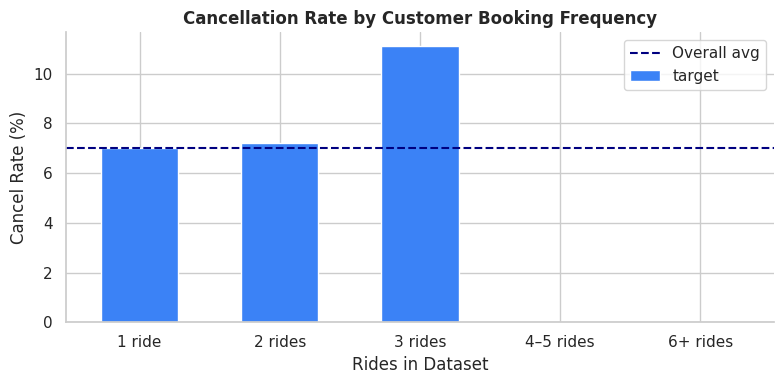

In [17]:
cust_freq = df['Customer ID'].value_counts().to_dict()
df['customer_total_bookings'] = df['Customer ID'].map(cust_freq)

print('Customer booking frequency distribution:')
print(df['customer_total_bookings'].describe())

# Does frequency correlate with cancellation?
freq_bins = pd.cut(df['customer_total_bookings'], bins=[0,1,2,3,5,100],
                   labels=['1 ride', '2 rides', '3 rides', '4–5 rides', '6+ rides'])
cancel_by_freq = df.groupby(freq_bins, observed=False)['target'].mean() * 100

cancel_by_freq.plot(kind='bar', color='#3b82f6', edgecolor='white', figsize=(8, 4), width=0.55)
plt.title('Cancellation Rate by Customer Booking Frequency', fontweight='bold')
plt.ylabel('Cancel Rate (%)')
plt.xlabel('Rides in Dataset')
plt.xticks(rotation=0)
plt.axhline(df['target'].mean()*100, color='navy', linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

### 7f. Feature Correlation with Target

Now that all features are numeric, we can check which ones are most correlated with `target`. High correlation = the model has more to work with.

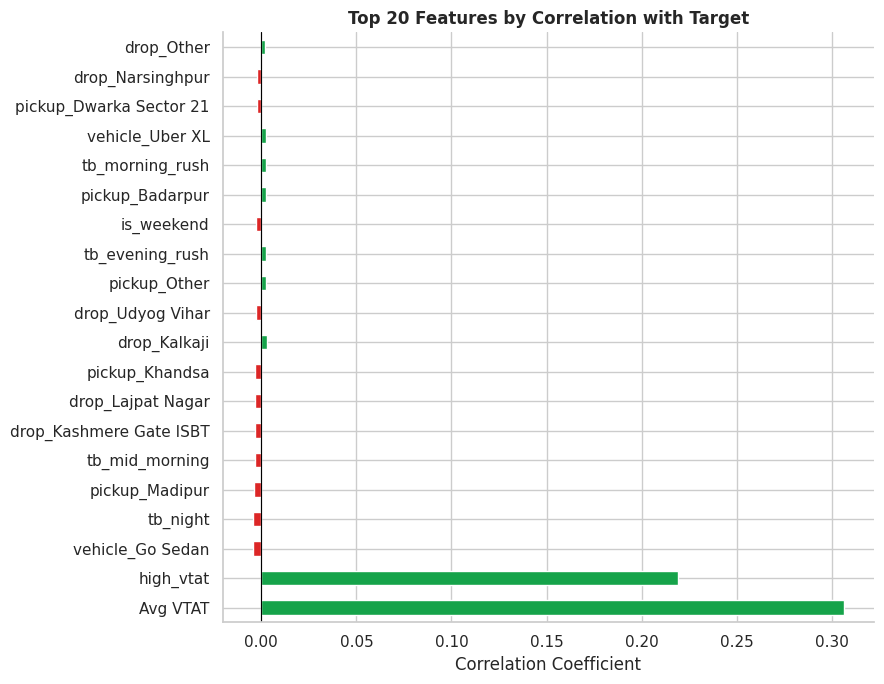

Green = positively correlated with cancellation
Red   = negatively correlated (this feature makes cancellation less likely)


In [18]:
# Collect all engineered numeric features
ALL_FEATURES = (
    ['hour', 'weekday', 'is_weekend', 'month', 'Avg VTAT', 'high_vtat', 'customer_total_bookings']
    + vehicle_cols
    + pickup_cols
    + drop_cols
    + [c for c in df.columns if c.startswith('tb_')]
)

# Compute correlation with target
corr_df = df[ALL_FEATURES + ['target']].corr()['target'].drop('target')
corr_df = corr_df.sort_values(key=abs, ascending=False)

# Plot top 20
top_corr = corr_df.head(20)
colors = ['#16a34a' if v > 0 else '#dc2626' for v in top_corr.values]

top_corr.plot(kind='barh', color=colors, figsize=(9, 7), edgecolor='white')
plt.title('Top 20 Features by Correlation with Target', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Green = positively correlated with cancellation')
print('Red   = negatively correlated (this feature makes cancellation less likely)')

---
## Step 8: Handle Class Imbalance

Only ~7% of rides are customer cancellations. If we just train a model on this, it will learn to almost always predict `0` — because that's right 93% of the time.

We fix this by telling the model to **weight each cancellation more heavily** during training. Scikit-learn makes this easy with `class_weight='balanced'`.

In [19]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['target']
)
weights = dict(enumerate(class_weights))
print('Class weights:', {k: round(v, 2) for k, v in weights.items()})
print()
print('What this means:')
print('  Class 0 (not cancelled) → weight ~0.5x — these are very common, so each one matters less')
print('  Class 1 (cancelled)     → weight ~7x  — these are rare, so the model pays more attention to each one')

Class weights: {0: np.float64(0.54), 1: np.float64(7.14)}

What this means:
  Class 0 (not cancelled) → weight ~0.5x — these are very common, so each one matters less
  Class 1 (cancelled)     → weight ~7x  — these are rare, so the model pays more attention to each one


---
## Step 9: Prepare Data & Split

We select only the features that are:
- Available at booking time (no leakage)
- Already numeric (encoded in Step 7)

Then split 80% for training, 20% for testing.

In [20]:
TARGET = 'target'
FEATURES = (
    ['hour', 'weekday', 'is_weekend', 'month', 'Avg VTAT', 'high_vtat', 'customer_total_bookings']
    + vehicle_cols
    + pickup_cols
    + drop_cols
    + [c for c in df.columns if c.startswith('tb_')]
)

X = df[FEATURES]
y = df[TARGET]

# Impute any remaining nulls with column median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Training set:  {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Testing set:   {len(X_test):,} rows   ({len(X_test)/len(X)*100:.0f}%)')
print(f'Total features: {len(FEATURES)}')
print(f'\nCancel rate — Train: {y_train.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%  (stratify worked ✅)')

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training set:  120,000 rows  (80%)
Testing set:   30,000 rows   (20%)
Total features: 39

Cancel rate — Train: 7.0%  |  Test: 7.0%  (stratify worked ✅)


---
## Step 10: Train the Models

In [21]:
# ── Logistic Regression ──────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print('🔵 Logistic Regression trained')
print(f'   ROC AUC: {roc_auc_score(y_test, lr_prob):.3f}')

🔵 Logistic Regression trained
   ROC AUC: 0.764


In [22]:
# ── Decision Tree ────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

print('🟠 Decision Tree trained')
print(f'   ROC AUC: {roc_auc_score(y_test, dt_prob):.3f}')

🟠 Decision Tree trained
   ROC AUC: 0.777


---
## Step 11: Evaluate the Models

We use three lenses:
- **Confusion matrix** - visual breakdown of what the model got right and wrong
- **Classification report** - precision, recall, F1 per class
- **ROC AUC** - overall ability to distinguish cancellations from non-cancellations (1.0 = perfect, 0.5 = random)

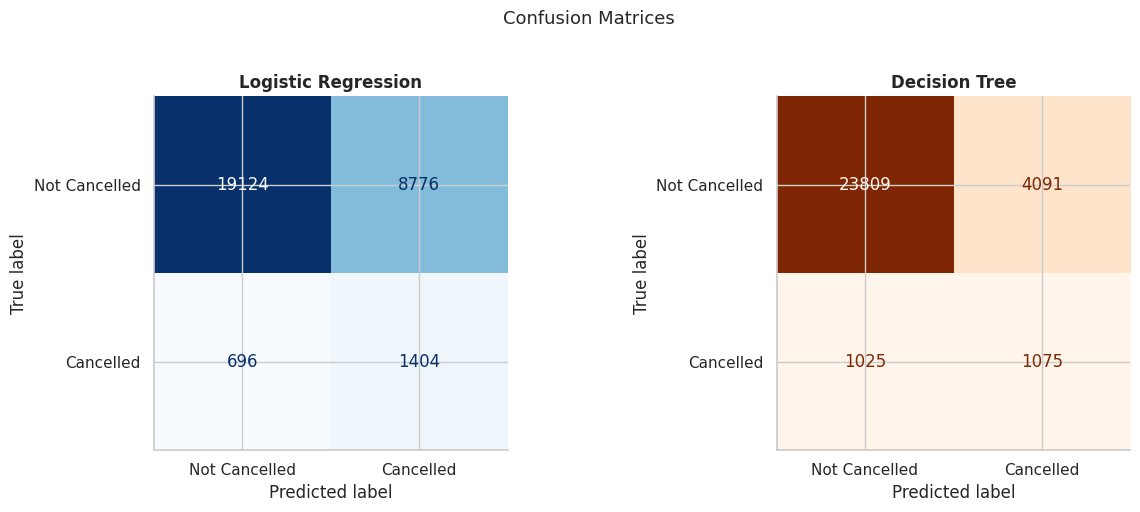

Reading the matrix:
  Top-left  (TN): Correctly predicted NOT cancelled
  Top-right (FP): Predicted cancelled, actually was not  ← false alarm
  Bot-left  (FN): Predicted NOT cancelled, actually WAS  ← missed cancellation
  Bot-right (TP): Correctly predicted cancelled          ← want this high!


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title, cmap in zip(
    axes,
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Not Cancelled', 'Cancelled']).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(title, fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Reading the matrix:')
print('  Top-left  (TN): Correctly predicted NOT cancelled')
print('  Top-right (FP): Predicted cancelled, actually was not  ← false alarm')
print('  Bot-left  (FN): Predicted NOT cancelled, actually WAS  ← missed cancellation')
print('  Bot-right (TP): Correctly predicted cancelled          ← want this high!')

In [24]:
print('=' * 55)
print('🔵 LOGISTIC REGRESSION')
print('=' * 55)
print(classification_report(y_test, lr_pred,
      target_names=['Not Cancelled', 'Cancelled'], digits=3))
print(f'ROC AUC: {roc_auc_score(y_test, lr_prob):.3f}')

print()
print('=' * 55)
print('🟠 DECISION TREE')
print('=' * 55)
print(classification_report(y_test, dt_pred,
      target_names=['Not Cancelled', 'Cancelled'], digits=3))
print(f'ROC AUC: {roc_auc_score(y_test, dt_prob):.3f}')

🔵 LOGISTIC REGRESSION
               precision    recall  f1-score   support

Not Cancelled      0.965     0.685     0.802     27900
    Cancelled      0.138     0.669     0.229      2100

     accuracy                          0.684     30000
    macro avg      0.551     0.677     0.515     30000
 weighted avg      0.907     0.684     0.761     30000

ROC AUC: 0.764

🟠 DECISION TREE
               precision    recall  f1-score   support

Not Cancelled      0.959     0.853     0.903     27900
    Cancelled      0.208     0.512     0.296      2100

     accuracy                          0.829     30000
    macro avg      0.583     0.683     0.599     30000
 weighted avg      0.906     0.829     0.860     30000

ROC AUC: 0.777


Model comparison (for cancelled class):
                     ROC AUC  Precision  Recall    F1
Model                                                
Logistic Regression     76.4       13.8    66.9  22.9
Decision Tree           77.7       20.8    51.2  29.6 %


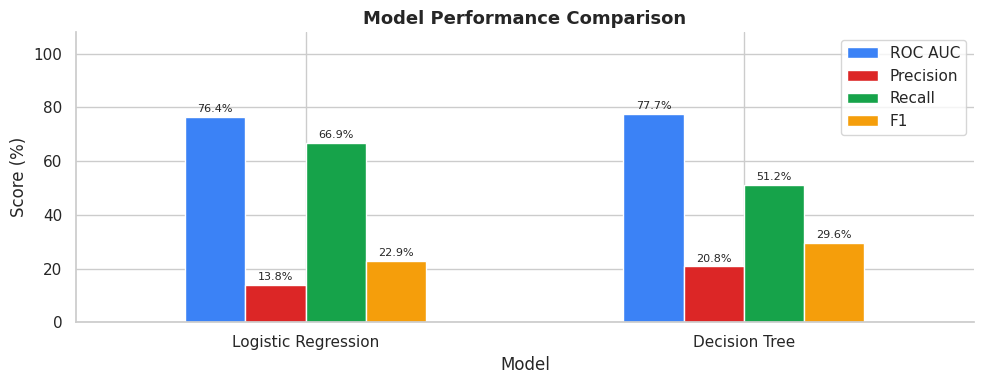

In [25]:
# Side-by-side metric comparison
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Decision Tree'],
    'ROC AUC':   [roc_auc_score(y_test, lr_prob), roc_auc_score(y_test, dt_prob)],
    'Precision': [precision_score(y_test, lr_pred, zero_division=0),
                  precision_score(y_test, dt_pred, zero_division=0)],
    'Recall':    [recall_score(y_test, lr_pred), recall_score(y_test, dt_pred)],
    'F1':        [f1_score(y_test, lr_pred, zero_division=0),
                  f1_score(y_test, dt_pred, zero_division=0)],
}).set_index('Model')

print('Model comparison (for cancelled class):')
print((results * 100).round(1).to_string() + ' %')

ax = (results * 100).plot(kind='bar', figsize=(10, 4), width=0.55, edgecolor='white',
     color=['#3b82f6', '#dc2626', '#16a34a', '#f59e0b'])
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 108)
ax.set_xticklabels(results.index, rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

---
## Step 12: Visualise the Decision Tree & Feature Importance

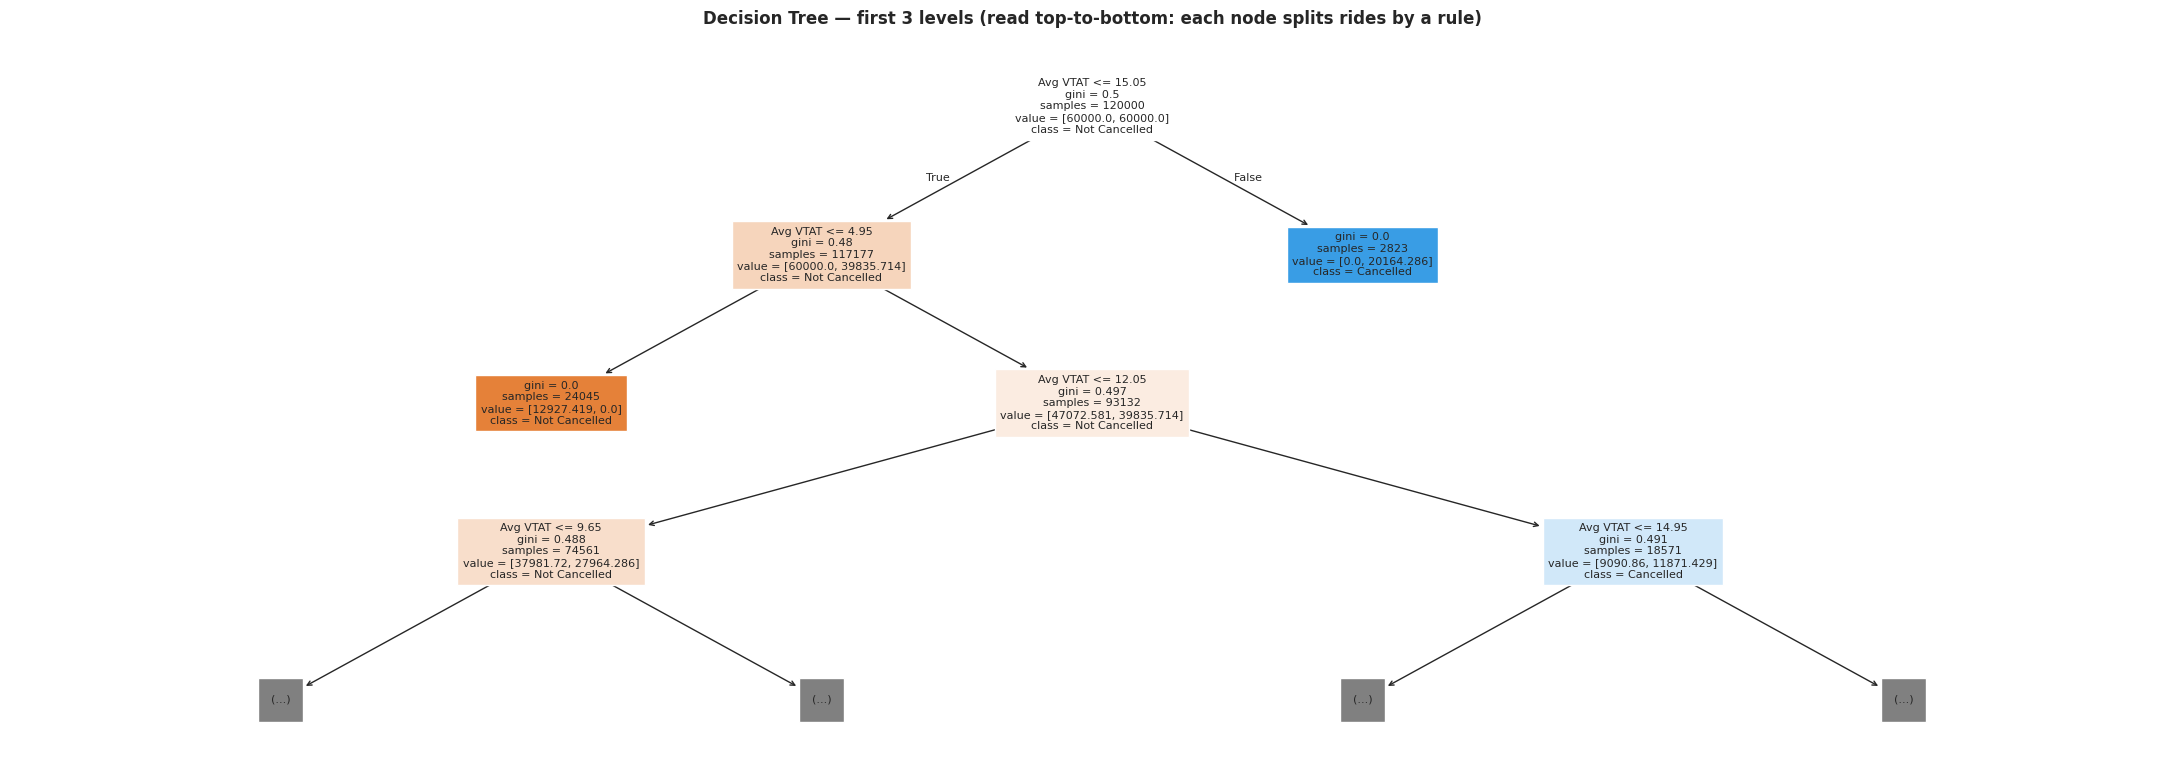

In [26]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt, feature_names=FEATURES,
    class_names=['Not Cancelled', 'Cancelled'],
    filled=True, max_depth=3, fontsize=8, ax=ax
)
plt.title('Decision Tree — first 3 levels (read top-to-bottom: each node splits rides by a rule)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

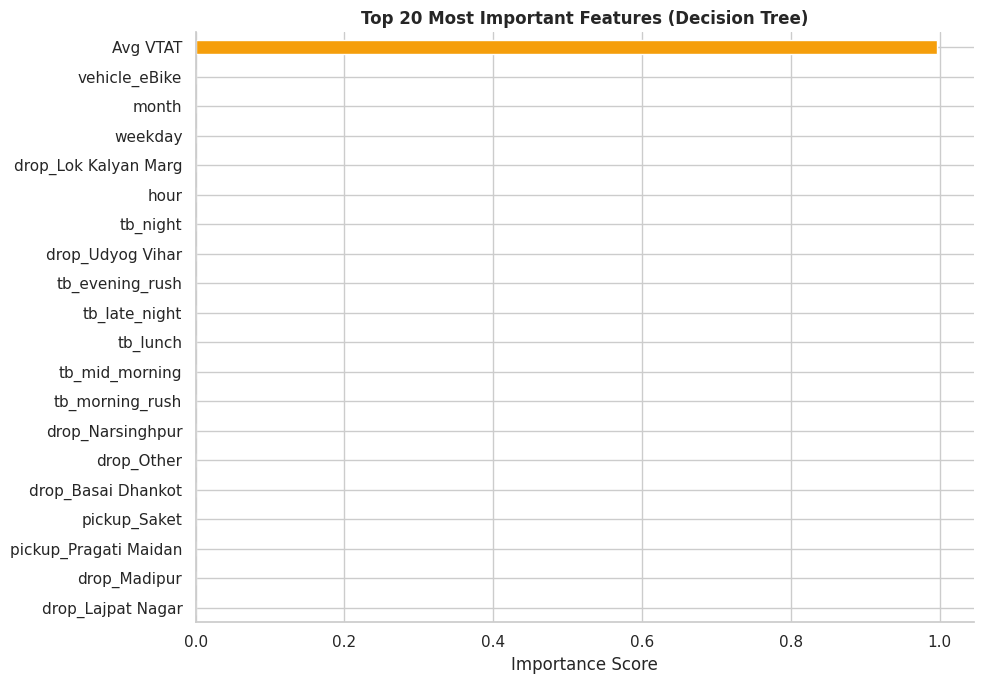

Top 5 features:
  Avg VTAT                                 0.9965
  vehicle_eBike                            0.0012
  month                                    0.0011
  weekday                                  0.0006
  drop_Lok Kalyan Marg                     0.0006


In [27]:
# Decision Tree feature importance
importance = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=True)
top20 = importance.tail(20)

top20.plot(kind='barh', figsize=(10, 7), color='#f59e0b', edgecolor='white')
plt.title('Top 20 Most Important Features (Decision Tree)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for feat, score in importance.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:<40} {score:.4f}')

---
## Step 13: Final Summary

<div style="background-color:#0f172a; color:#e2e8f0; padding:22px; border-radius:10px; font-family:Calibri; font-size:16px; line-height:1.9em;">

**What we built:**
- 🎯 Predicting customer-initiated ride cancellations (7% of all rides)
- 🔧 Engineered meaningful features: vehicle encoding, top location flags, time-of-day buckets, VTAT pressure signal, customer frequency
- ⚖️ Handled class imbalance with balanced class weights
- 🤖 Trained and compared Logistic Regression vs Decision Tree
- 📊 Evaluated with Confusion Matrix, Precision/Recall, F1, and ROC AUC

**Key lessons:**
- **Null values aren't always noise** — understand *why* they're missing before filling or dropping
- **Leakage is a silent killer** — always ask: "would I know this at prediction time?"
- **Accuracy is misleading on imbalanced data** — check Recall for the minority class
- **Feature engineering matters more than model choice** — good signals beat a fancy algorithm


**🚀 Challenges to try next:**
- Encode all 176 pickup locations using their historical cancel rate (target encoding)
- Try a `RandomForestClassifier` — does it beat the Decision Tree?
- Plot a ROC curve for both models on the same chart
- What happens if you remove `high_vtat` — how much does performance drop?

</div>

### 💡 Business Insights & Recommendations

- **1. Wait Time is Everything**
Despite engineering 39 different features, the Decision Tree model relied on `Avg VTAT` (Average Vehicle Time to Arrival) for 99.65% of its predictive power. Time of day and location only matter because they influence traffic and wait times.

- **2. The Business Metric: Recall**
Our models achieved an ROC AUC of ~0.77. For this specific business problem, Recall is our most important metric. Missing a cancellation (False Negative) costs the company an entire fare, whereas falsely flagging a safe ride (False Positive) might only cost a small retention discount.

- **Recommendation:** The app should implement an automated trigger: if the estimated VTAT crosses a specific high-risk threshold, immediately offer the customer a small discount or loyalty points to incentivize them to wait instead of cancelling.